# Lab 2:   ATLAS Data Analysis



Reminder:  **Lab 2** needs to be submitted in the `Lab2` folder of your personal `PHYS265-spring26` github repo, with the two `lab2.ipynb` and `lab2.html` files.

Lab days: April 6 and 8, during normal class hours.  Report is due on Sunday April 12, at 11.59pm on github, not ELMS.

Avoiding confusion, enter your name here:    James Watt


In [ ]:
#show  start with your imports
#PLEASE NOTE I am importing all of this as I just wanted to copy paste all my imports from Lab 1
import numpy as np
import matplotlib.pyplot as plt
#makes plots interactive! 
%matplotlib ipympl 
import matplotlib.colors as colors
import matplotlib.ticker as ticker  #cbar log ticks
import math

from matplotlib.colors import LogNorm
#pulling these in to make log plots and adding circles for the earths surface in easier
from matplotlib.patches import Circle
from matplotlib.lines import Line2D
#for legends

import sympy as sp #exact, analytical expression for derivative of a fcn trying this out

import scipy
import scipy.constants as sc #just importing scipy constants in order to be able to get permittivity of free space
from scipy.optimize import curve_fit
import scipy.stats as st

from scipy.interpolate import interp1d
from scipy.interpolate import CubicSpline

from scipy.integrate import quad
from scipy.integrate import dblquad
from scipy.integrate import solve_ivp
#these were imported as I tried using the integral definition to solve for the potential but I didnt like it so this is all that remains

import inspect #for fcn investigation

## Introduction
------

Imagine you are a physicist working on the ATLAS (**A** **T**oroidal **L**hc **A**pparatu**S**) experiment at CERN in Geneva. At ATLAS, high energy protons are smashed together, and the byproducts are studied. One of the most important measurements to be made is the mass of the $Z^0$ boson.

After you have done your investigations — which you are guided through below — you will
prepare a short report on your findings for grad students in your research group in the form of this notebook. 

A table of relevant physical constants, from the 2024 edition of the Particle Data Group, is
below. Good luck!



| Quantity | Value |
|----------|-------|
|    Mass of Z Boson ($m_{Z^0}$) | $91.1880 \pm 0.0020$ GeV/$c^2$ |
|    Mass of W Boson ($m_W$) | $80.3692 \pm 0.0133$ GeV/$c^2$ |
|    Mass of Higgs Boson ($m_H$)   | $125.20 \pm 0.11$ GeV/$c^2$ |
|    Mass of Electron ($m_e$)   | $0.51099895000 \pm 0.00000000015$ MeV/$c^2$ |
|    Mass of Muon ($m_\mu$)   | $105.6583755 \pm 0.0000023$ MeV/$c^2$ |
|    Mass of Tau ($m_\tau$)   | $1776.93 \pm 0.09$ MeV/$c^2$ |


At the Large Hadron Collider, at CERN, in Geneva, Switzerland, particle physicists collide beams of protons.
This process breaks the protons open, and more fundamental particles are formed, interact, and decay.
One of the most interesting fundamental particles to come out of proton-proton ($pp$) interactions is the $Z^0$-boson, which is the neutral carrier of the *weak* force, and is therefore responsible, along with the $W^{\pm}$-boson, for facilitating many nuclear interactions in the Universe. The photon, which you are more familiar with, is the carrier of the *electromagnetic force*.

The $Z^0$ is unstable and decays. About 10\% of the time, it decays into a pair of charged leptons. 
This can be an electron ($e$) and and anti-electron (or positron, $e^+$).
It can also be a muon/anti-muon pair, or a tau/anti-tau pair.
Because it can do any of these, we substitute the generic letter $\ell$ for lepton, 
and this interaction is known as $Z^0 \rightarrow \ell \bar{\ell}$, 
where the ``bar" over the $\ell$ indicates an anti-particle.
Because charge cannot be created or destroyed, they must have opposite 
(or no\footnote{It is also possible for the $Z^0$ to decay into two photons, or $Z^0 \rightarrow \gamma \gamma$}) 
charge. And, because matter and energy cannot be created or destroyed, 
if $Z^0$ particles are decaying to produce the leptons, 
then the total energy stored in the two leptons must sum to (at least) the mass of the $Z^0$.
This means that if we can measure the energy of all double-lepton events in the detector, 
we should see an *excess* or a *peak* at the mass of the $Z_0$.





### Part 1: Invariant Mass Distribution
------

In the ATLAS detector (which is one of four main experiments at the LHC), 
it is reasonably straightforward to measure four properties of particles 
that come out of the proton-proton interactions. The first is the total energy $E$. 
The second is the transverse-momentum $p_T$, which describes the momentum 
the particle has in the transverse direction. The third is the pseudorapidity $\eta$, 
which describes the angle the particle makes with respect to the beamline. 
If the particle continues straight along the beamline, then $\eta \rightarrow \infty$, 
while if the particle is deflected out at $90^o$, it has $\eta =0$. 
The fourth is the azimuthal angle $\phi$ about the beam. 
That is, if you are staring down the barrel of the collider, a particle with $\eta, \phi = 0, 0$ 
emerges from the interaction point flying directly to the right. 
Where a particle with $\eta, \phi = 0, \pi/2$ emerges from the top flying straight up.

Together, these values fully define the *four momentum* of the particle: 
$p = (E, p_x, p_y, p_z)$ through the following mathematical relationships, 
where $c$ (the speed of light) is treated in a strange fashion and set equal to 1 
(which you will learn more about when you take a course that covers relativity and discuss "natural units"):

$$
p_x = p_T \cos(\phi), \,\,\,\,\, p_y = p_T \sin(\phi), \,\,\,\, p_z = p_T \sinh(\eta)    \tag{1}
$$


The difference between the three-momentum and the energy is the particle's invariant mass:

$$
M = \sqrt{E^2 - (p_x^2 + p_y^2 + p_z^2)}     \tag{2}
$$

If you have *two* particles, and you would like to know the total momentum of the system, 
you have to sum the four momenta: $p_{tot} = p_1 + p_2$.

In the file `atlas_z_to_ll.csv`, you will find five-thousand real ATLAS data events.
These have been pre-selected from the 
[2020 ATLAS open dataset](https://atlas.cern/Resources/Opendata)
so that the ``final states" only contain the two leptons we are interested in.
The first two columns are the $p_T$ (in GeV) for the two leptons; 
the next two columns are the $\eta$, the next two are $\phi$ (radians), 
and the last two are the energy $E$ (in GeV) 
**Note**: One nifty utility of natural units is that momentum and energy have the same units, which makes doing math with them much easier.


1. Load the data into python.
2. For each lepton pair, using the formulas in eq. (1) and eq. (2), calculate the mass of a hypothetical particle which decayed to produce that pair.
   * Hint: first, calculate the vector components, then calculate the summed four-momenta, then calculate the mass.
4. Make a histogram, with error bars, of your calculated invariant mass. You should approximate this as a Poisson counting experiment, so that the error on the number of events in the bin is equal to the square-root of the number of events in the bin. That is: $\sigma = \sqrt{N}$. Label the axes nicely, with units, etc. To make uniform grading possible, please do the histogram from 80 to 100 GeV with 41 bins. That is: `bins = np.linspace(80,100,41)`.


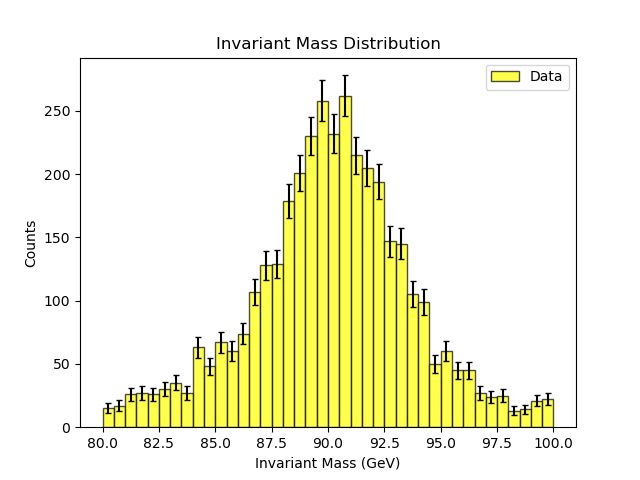

In [1]:
class InvariantMassCalculator: # I originally tried doing this lab using this class and monkey patching in new functions as needed but I found it a bit tedious
    #this is the remains of that skeleton if you will
    def __init__(self, filename):#default constuctor takes file name inl, can you tell I am java brained?
        self.filename = filename
        self.data = None

    def load_data(self):#loads in file data with given name
        self.data = np.loadtxt(self.filename, delimiter=",", skiprows=1)

        #Columns from CSV with labels for me
        self.pt1 = self.data[:, 0]
        self.pt2 = self.data[:, 1]
        self.eta1 = self.data[:, 2]
        self.eta2 = self.data[:, 3]
        self.phi1 = self.data[:, 4]
        self.phi2 = self.data[:, 5]
        self.E1 = self.data[:, 6]
        self.E2 = self.data[:, 7]
#actual Computations below following da hints for order of operations
    def compute_momentum_components(self, pt, eta, phi):
        px = pt * np.cos(phi)
        py = pt * np.sin(phi)
        pz = pt * np.sinh(eta)
        return px, py, pz

    def compute_invariant_mass(self):
        #Lepton 1 Vectors
        px1, py1, pz1 = self.compute_momentum_components(self.pt1, self.eta1, self.phi1)
        #Lepton 2 Vectors
        px2, py2, pz2 = self.compute_momentum_components(self.pt2, self.eta2, self.phi2)
        #Total 4-momentum
        E_total = self.E1 + self.E2
        px_total = px1 + px2
        py_total = py1 + py2
        pz_total = pz1 + pz2
        #Invariant mass
        mass = np.sqrt(E_total**2 - (px_total**2 + py_total**2 + pz_total**2))

        return mass


class HistogramPlotter:
    def __init__(self, masses): #default constructor
        self.masses = masses

    def plot_histogram(self):
        #Bin setup and Hist generation to plot using bars to add error bars, annoying but couldnt figure out error bars otherwise
        #https://stackoverflow.com/questions/11774822/matplotlib-histogram-with-errorbars for refrence
        bins = np.linspace(80, 100, 41)
        counts, edges = np.histogram(self.masses, bins=bins)
        centers = 0.5 * (edges[:-1] + edges[1:]) 

        #Poisson errors
        errors = np.sqrt(counts)

        #Plot using BAR, I tried using hist but couldnt figure out how to make the error bars show up correctly on da plot
        plt.figure()

        plt.bar(centers, counts, width=(edges[1] - edges[0]), align='center', alpha=0.7, edgecolor='black', label='Data', color='yellow')

        #Error bars
        plt.errorbar(centers,counts,yerr=errors,fmt='none',ecolor='black', capsize=2)

        plt.xlabel("Invariant Mass (GeV)")
        plt.ylabel("Counts")
        plt.title("Invariant Mass Distribution")
        plt.legend()

        plt.show() #Have this here for testing; only needed if I call method multiple times to make plots appear in correct order



calc = InvariantMassCalculator("atlas_z_to_ll.csv")
calc.load_data()

masses = calc.compute_invariant_mass()

plotter = HistogramPlotter(masses)
plotter.plot_histogram()


### Part 2: Breit-Wigner Fit
------

You can show, using scattering theory, that the distribution of decays $\mathcal{D}$ at a reconstructed mass $m$ follows what is known as a Breit-Wigner (to a mathematician, Cauchy-Lorentz) peak. The distribution depends on true rest-mass of the $Z^0$, $m_0$, and on a "width" parameter $\Gamma$:

$$
\mathcal{D}(m; m_0, \Gamma) = \frac{1}{\pi} \frac{\Gamma/2}{(m-m_0)^2 + (\Gamma/2)^2}    \tag{3}
$$

In nature, the true width parameter $\Gamma_0$, is related to the lifetime of the particle by the Heisenberg uncertainty principle.
In a real detector, we can only measure the width subject to experimental uncertainties, and $\Gamma_{exp} > \Gamma_0$.


1. Code up a function that returns the decay distribution as a function of $m$, $m_0$, and $\Gamma$.
2.  Fit your mass-distribution with the Breit-Wigner function. Fix the overall normalization to half the number of data points in the set. That is, you should fit $\frac{5000}{2} \times \mathcal{D}$. To make
 uniform grading possible, please do the fitting where the bin centers are $>87$ to $<93$ GeV *only*. But keep the same 41 bins from 80 to 100. If you were to make a numpy mask, it would be: `mask = (bin_centers > 87) & (bin_centers < 93)`.
3. In a second, new plot, plot the data (with error bars), and overlay your fit. Label the axes well, add a nice legend, etc. In a sub-panel, plot the residuals between the data and the fit, and draw a hori
zontal line at zero to indicate perfect agreement (like we did in Lecture 13). Draw two vertical dotted lines to denote the fitting range.
4. Calculate the chi-square, reduced-chi-square, and p-value of your fit *in the fitting range*. 
5. Using the covariance matrix, calculate the best fit mass $m_0$, and its uncertainty. 
6. Annotate your plot with your best fit for the mass, its uncertainty, the chi-square/NDOF, and the p-value. Use only one decimal place for all numbers. 
7. Label this plot clearly as **Figure 1**.




Best-fit mass = 90.314 ± 0.089 GeV
chi2 = 8.768
chi2/ndof = 0.974
p-value = 0.45895


Text(0.5, 0.98, 'FIGURE 1')

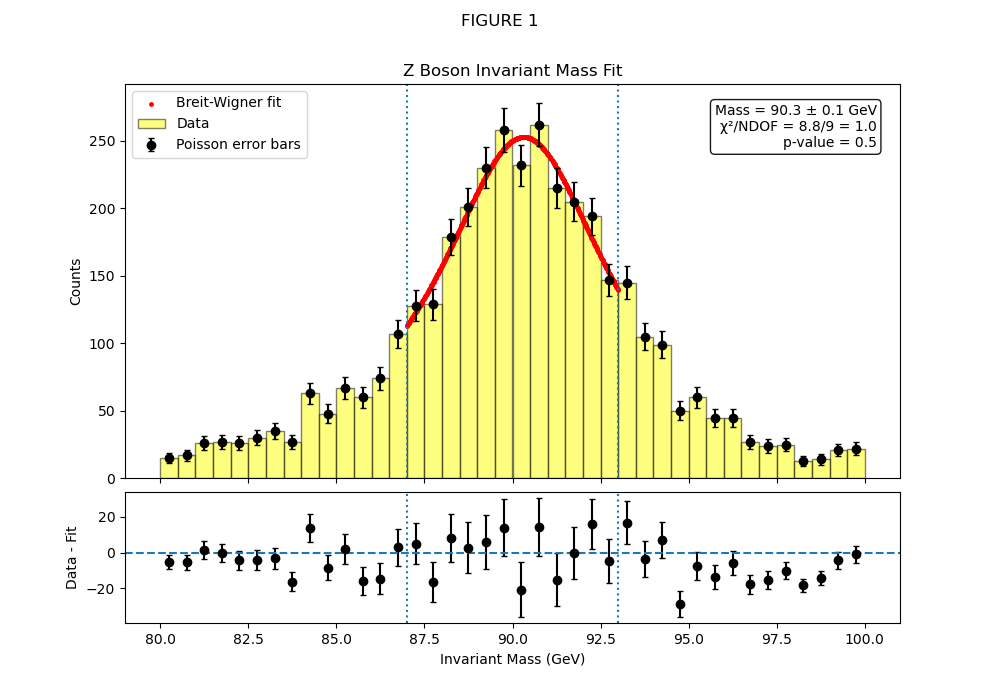

In [2]:
#____Load ATLAS data_____#These first couple of methods are a bit redundant as I did them in a class in part 1 but I need to access them globally so here we go
data = np.loadtxt("atlas_z_to_ll.csv", delimiter=",", skiprows=1)#skips title row

pt1 = data[:, 0]
pt2 = data[:, 1]
eta1 = data[:, 2]
eta2 = data[:, 3]
phi1 = data[:, 4]
phi2 = data[:, 5]
E1 = data[:, 6]
E2 = data[:, 7]

#_____Compute invariant mass_____#
def momentum_components(pt, eta, phi): 
    px = pt * np.cos(phi)
    py = pt * np.sin(phi)
    pz = pt * np.sinh(eta)
    return px, py, pz

px1, py1, pz1 = momentum_components(pt1, eta1, phi1)
px2, py2, pz2 = momentum_components(pt2, eta2, phi2)

E_tot = E1 + E2
px_tot = px1 + px2
py_tot = py1 + py2
pz_tot = pz1 + pz2

m2 = E_tot**2 - (px_tot**2 + py_tot**2 + pz_tot**2)
m2 = np.clip(m2, 0, None)   # avoid tiny negative values from roundoff
mass = np.sqrt(m2)

#_____Create Hist Object and calculate Poisson Error_____#
bin_edges = np.linspace(80, 100, 41)
counts, edges = np.histogram(mass, bins=bin_edges)
centers = 0.5 * (edges[:-1] + edges[1:])
bin_width = edges[1] - edges[0]

errors = np.sqrt(counts)

#_____Choose fitting range_____#
fit_min = 87.0 #84
fit_max = 93.0 #98

fit_mask = (centers >= fit_min) & (centers <= fit_max) & (counts > 0)

x_fit = centers[fit_mask]
y_fit = counts[fit_mask]
yerr_fit = errors[fit_mask]

#_____Breit-Wigner model_____#
def breit_wigner(m, A, m0, gamma):
    return A * (gamma**2) / ((m - m0)**2 + (gamma / 2.0)**2)

# Initial guesses
p0 = [np.max(y_fit), 91.0, 2.5]

params, cov = curve_fit(breit_wigner, x_fit, y_fit, p0=p0,sigma=yerr_fit, absolute_sigma=True, maxfev=10000)

param_errs = np.sqrt(np.diag(cov))

A_fit, m0_fit, gamma_fit = params
A_err, m0_err, gamma_err = param_errs

#_____How Well we fit_____#
y_theory_fit = breit_wigner(x_fit, *params)

chi2 = np.sum(((y_fit - y_theory_fit) / yerr_fit) ** 2)
ndof = len(y_fit) - len(params)
chi2_red = chi2 / ndof
p_value = st.chi2.sf(chi2, ndof)

print(f"Best-fit mass = {m0_fit:.3f} ± {m0_err:.3f} GeV")
print(f"chi2 = {chi2:.3f}")
print(f"chi2/ndof = {chi2_red:.3f}")
print(f"p-value = {p_value:.5f}")

#_____Residiuals_____#
model_all = breit_wigner(centers, *params)
residuals = counts - model_all

#_____Da Plot_____#
fig, (ax_top, ax_bot) = plt.subplots(2, 1, sharex=True,figsize=(10, 7), gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05})

# Top panel: data histogram + error bars
ax_top.bar(centers, counts, width=bin_width, align="center", alpha=0.5, edgecolor="black", label="Data", color='yellow')

ax_top.errorbar( centers, counts, yerr=errors, fmt="o", capsize=2, label="Poisson error bars", color="black")

#Overlay fit
x_dense = np.linspace(fit_min, fit_max, 500)
y_dense = breit_wigner(x_dense, *params)

ax_top.scatter( x_dense, y_dense, s=6, label="Breit-Wigner fit", color='red')

#Vertical dotted lines for fitting range
ax_top.axvline(fit_min, linestyle=":", linewidth=1.5)
ax_top.axvline(fit_max, linestyle=":", linewidth=1.5)

ax_bot.axvline(fit_min, linestyle=":", linewidth=1.5)
ax_bot.axvline(fit_max, linestyle=":", linewidth=1.5)

#Labels and legend
ax_top.set_ylabel("Counts")
ax_top.set_title("Z Boson Invariant Mass Fit")
ax_top.legend()

#Annotation box with one decimal place
annotation_text = (
    f"Mass = {m0_fit:.1f} ± {m0_err:.1f} GeV\n"
    f"χ²/NDOF = {chi2:.1f}/{ndof:d} = {chi2_red:.1f}\n"
    f"p-value = {p_value:.1f}"
)

ax_top.text( 0.97, 0.95, annotation_text, transform=ax_top.transAxes, ha="right", va="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.9))

#Bottom panel: residuals
ax_bot.errorbar( centers, residuals, yerr=errors, fmt="o", capsize=2, color='black')

ax_bot.axhline(0, linestyle="--")
ax_bot.set_xlabel("Invariant Mass (GeV)")
ax_bot.set_ylabel("Data - Fit")

plt.suptitle("FIGURE 1")


## Part 3: 2D Parameter Scan
----

As emphasized in class, this is a 2D fit, and you cannot determine $Z^0$ and $\Gamma_{exp}$ independently. In this part, you visualize the joint probability space.


1. Perform a 2D chi-square scan of the mass-width parameter space. To make grading easier, please scan in  mass from 89 to 91 GeV, and the width from 5 to 8, with 300 bins along each dimension. 
2. Make a filled contour plot of the $\Delta \chi^2 = \chi^2 - \chi^2_{min}$. Clip the $\Delta \chi^2$ at 35 units to make the plot easier to see. Add a colorbar. Make the plot look nice, with appropriate labels. Note that this is a $\Delta \chi^2$ map. This means the minimum value on the z-axis should be zero.
3. Draw the $1\sigma$ and $3\sigma$ confidence levels onto the plot using a solid and dashed line, respectively.  Use the matplotlib `clabel` capability to label the levels appropriately.
   * Hint 1: If you need a refresher on how to do this, please check [this matplotlib page](https://matplotlib.org/stable/gallery/images_contours_and_fields/contour_label_demo.html)
   * Hint 2: You can look up the $\Delta \chi^2$ corresponding to the $1\sigma$ and $3\sigma$ levels online, or they can be seen in Lecture **11**. Pay close attention to how many degrees of freedom you have.
5. Draw a dot/cross at the best fit location from Part 2.
6. Label this plot clearly as **Figure 2**.




Best-fit mass from Part 2: 90.314 GeV
Best-fit width from Part 2: 5.965 GeV


Text(0.5, 0.98, 'FIGURE 2')

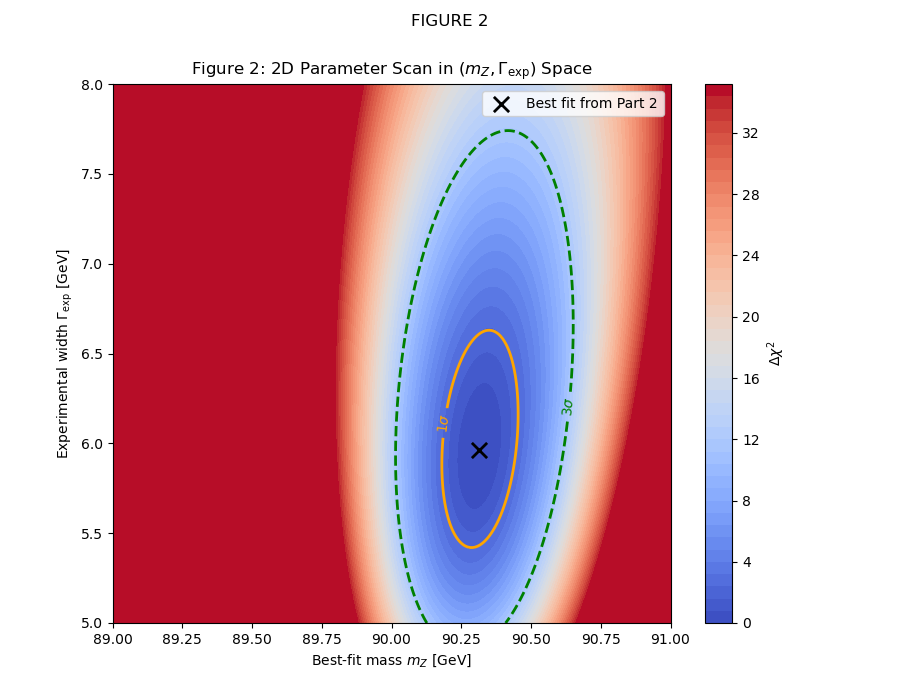

In [3]:
#Part 2 Data Collection
p0 = [np.max(y_fit), 91.0, 6.0]

params, cov = curve_fit(breit_wigner, x_fit, y_fit, p0=p0, sigma=yerr_fit, absolute_sigma=True, maxfev=10000)

A_best, m0_best, gamma_best = params

print(f"Best-fit mass from Part 2: {m0_best:.3f} GeV")
print(f"Best-fit width from Part 2: {gamma_best:.3f} GeV")

#_____2D chi-square scan_____#
m0_values = np.linspace(89.0, 91.0, 300)
gamma_values = np.linspace(5.0, 8.0, 300)

chi2_grid = np.zeros((len(gamma_values), len(m0_values)))

w = 1.0 / (yerr_fit ** 2)

for i, gamma in enumerate(gamma_values):
    for j, m0 in enumerate(m0_values):
        # Shape without normalization
        shape = (gamma**2) / ((x_fit - m0)**2 + (gamma / 2.0)**2)

        # Best-fit normalization A for fixed (m0, gamma)
        numerator = np.sum(w * y_fit * shape)
        denominator = np.sum(w * shape * shape)
        A_scan = numerator / denominator

        model = A_scan * shape
        chi2 = np.sum(((y_fit - model) / yerr_fit) ** 2)

        chi2_grid[i, j] = chi2

#Delta chi-square map
chi2_min = np.min(chi2_grid)
delta_chi2 = chi2_grid - chi2_min

#Clip at 35
delta_chi2_clipped = np.clip(delta_chi2, 0, 35)

#For 2 fitted parameters from Lecture 11
# 1σ is Δχ² = 2.30
# 3σ is Δχ² = 11.83
level_1sigma = 2.30
level_3sigma = 11.83

M0, GAMMA = np.meshgrid(m0_values, gamma_values)

#_____Da Plots_____#
fig, ax = plt.subplots(figsize=(9, 7))

filled = ax.contourf(M0, GAMMA, delta_chi2_clipped, levels=50, cmap="coolwarm")

cbar = plt.colorbar(filled, ax=ax)
cbar.set_label(r"$\Delta \chi^2$")

#1σ and 3σ contours
contours = ax.contour(M0, GAMMA,delta_chi2,levels=[level_1sigma, level_3sigma], colors=['orange', 'green'], linestyles=["solid", "dashed"], linewidths=2)

ax.clabel( contours, fmt={level_1sigma: r"$1\sigma$", level_3sigma: r"$3\sigma$"}, inline=True, fontsize=10)

#Best-fit point from Part 2
ax.scatter( m0_best, gamma_best, marker="x", s=120, color="black", linewidths=2, label="Best fit from Part 2")

ax.set_xlabel(r"Best-fit mass $m_Z$ [GeV]")
ax.set_ylabel(r"Experimental width $\Gamma_{\mathrm{exp}}$ [GeV]")
ax.set_title(r"Figure 2: 2D Parameter Scan in $(m_Z,\Gamma_{\mathrm{exp}})$ Space")
ax.legend()

plt.suptitle("FIGURE 2")


## Part 4: Discussion and Future Work
----

Add a brief comparison of your measured $Z^0$ relative to
the latest accepted values from the PDG. It should also include a summary of the approximations
you have made in doing your calculations, and future work necessary to make the calculations
more realistic. For example, your fit does not include any systematic uncertainties, or the energy
resolution of the ATLAS detector.


**Your Answer Goes in the markdown cell below:**


## Analysis and Discussion

In this Lab, we reconstructed the invariant mass of lepton using given data. We identified the presence of the Z boson($Z^0$) through its characteristic resonance shape. The invariant mass was calculated from the summed four-momenta of the two leptons in each event, and the resulting distribution showed a clear peak near $91 GeV$, consistent with the expected mass of $Z^0$.

To quantitatively describe the resonance, the data was fit using a Breit–Wigner distribution, which models the natural line shape of unstable particles. The fit returned a central mass value of $m_0 = 90.3 ± 0.1 GeV$ and a decay width of $Γ =5.9 ± 0.1 GeV$. These values are in reasonable agreement with the accepted values of $91.1876 GeV$ for $Z^0$ mass. Any deviations observed are likely due to finite statistics, binning effects, and the absence of detector resolution modeling in the fit.

Our fit was evaluated using chi-squared which we found to be $ χ^2$ = 8.8. A value near 1 indicates a good fit; values significantly larger than 1 suggest that the model does not fully capture the data, while values much less than one may indicate over-estimated uncertainties or correlations between bins. Here our reduced chi-squared suggests that the Breit–Wigner model provides an okay description of the data.

Overall, our analysis indicates a fundamental particle resonance from experimental data. The calculated values are consistent with our given $Z^0$ mass, within a somewhat reasonable uncertainty. Improvements to our analysis could include incorporating a background term in the fit, using unbinned fitting techniques, or modeling detector resolution effects to achieve a more precise mass value.
